# TDA + XGBoost para Trading de Criptomonedas
## Distancia de Wasserstein como Feature Topológico

**Proyecto:** Topological Data Analysis (TDA) aplicado a series de tiempo financieras  
**Alumno:** Kevin  
**Datos:** OHLCV de Binance (parquet, múltiples pares USDT)  

---

### Metodología

1. **Embedding de Takens**: Cada ventana de precio se convierte en una nube de puntos mediante el teorema de Takens.
2. **Homología Persistente** (Vietoris-Rips via `ripser`): H0 (componentes conectadas) y H1 (bucles/ciclos) por ventana.
3. **Distancia de Wasserstein** (`gudhi`): dos tipos de features topológicos:
   - *Amplitud de Wasserstein*: distancia de cada diagrama al diagrama vacío.
   - *Distancia temporal de Wasserstein*: cambio topológico entre ventanas consecutivas.
4. **XGBoost**: clasificador Buy / Hold / Sell sobre features TDA + indicadores técnicos clásicos.

### Dependencias (via `uv sync`)
```
ripser, gudhi, POT, xgboost, tqdm  (ver pyproject.toml)
```

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from tqdm.auto import tqdm

# --- TDA ---
from ripser import ripser                                  # Vietoris-Rips persistence
from gudhi.wasserstein import wasserstein_distance         # distancia W entre diagramas

# --- ML ---
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from matplotlib.patches import Patch

print('giotto-tda NO requerido — pipeline con ripser + numpy')
print(f'ripser OK | xgboost {xgb.__version__} | gudhi OK')

giotto-tda NO requerido — pipeline con ripser + numpy
ripser OK | xgboost 3.2.0 | gudhi OK


## 1. Configuración

In [2]:
# ── Rutas ──────────────────────────────────────────────────────────────────
DATA_DIR = Path(r"D:\Kevin\Posgrados\MCD\2026-1\proyecto-tda\trading_tda\freqtrade\user_data\data\binance")

# ── Par y temporalidad ─────────────────────────────────────────────────────
SYMBOL    = "BTC_USDT"   # ADA_USDT | BNB_USDT | BTC_USDT | DOGE_USDT | ETH_USDT | SOL_USDT | XRP_USDT
TIMEFRAME = "15m"        # 15m | 4h

# ── Filtro de datos ────────────────────────────────────────────────────────
LOOKBACK_YEARS = 2       # usar solo los últimos N años (rendimiento)

# ── TDA ────────────────────────────────────────────────────────────────────
WINDOW_SIZE   = 50       # candles por ventana
STRIDE        = 4        # paso (4 x 15m = 1h entre muestras TDA)
TAKENS_DIM    = 3        # dimensión del embedding de Takens
TAKENS_DELAY  = 2        # retardo temporal τ

# ── Señal objetivo ─────────────────────────────────────────────────────────
FUTURE_PERIODS = 16      # horizontes adelante (16 x 15m = 4h)
BUY_THRESHOLD  =  0.015  # retorno futuro >  1.5% → Buy
SELL_THRESHOLD = -0.015  # retorno futuro < -1.5% → Sell

# ── Split y backtesting ────────────────────────────────────────────────────
TRAIN_FRAC      = 0.80
INITIAL_CAPITAL = 10_000.0
FEE             = 0.001

print(f"Par: {SYMBOL} | TF: {TIMEFRAME} | Window: {WINDOW_SIZE} | Stride: {STRIDE}")
print(f"Takens: dim={TAKENS_DIM}, τ={TAKENS_DELAY} | Target: {FUTURE_PERIODS}×15m={FUTURE_PERIODS*15}min")

Par: BTC_USDT | TF: 15m | Window: 50 | Stride: 4
Takens: dim=3, τ=2 | Target: 16×15m=240min


## 2. Carga y EDA

In [3]:
def load_ohlcv(symbol: str, timeframe: str, data_dir: Path = DATA_DIR) -> pd.DataFrame:
    df = pd.read_parquet(data_dir / f"{symbol}-{timeframe}.parquet")
    df = df.set_index('date').sort_index()
    df.index = df.index.tz_convert('UTC')
    return df


df_full = load_ohlcv(SYMBOL, TIMEFRAME)
cutoff  = df_full.index.max() - pd.DateOffset(years=LOOKBACK_YEARS)
df      = df_full[df_full.index >= cutoff].copy()

print(f"Total disponible : {df_full.shape[0]:,} velas")
print(f"Usando           : {df.shape[0]:,} velas  ({df.index.min().date()} → {df.index.max().date()})")
df.head(3)

Total disponible : 140,250 velas
Usando           : 70,081 velas  (2024-05-15 → 2026-05-15)


,open,high,low,close,volume
date,,,,,
2024-05-15 23:30:00+00:00,66235.51,66444.16,66142.33,66331.02,372.24089
2024-05-15 23:45:00+00:00,66331.02,66376.00,66185.97,66206.50,361.92323
2024-05-16 00:00:00+00:00,66206.51,66666.00,66206.50,66377.84,759.83362


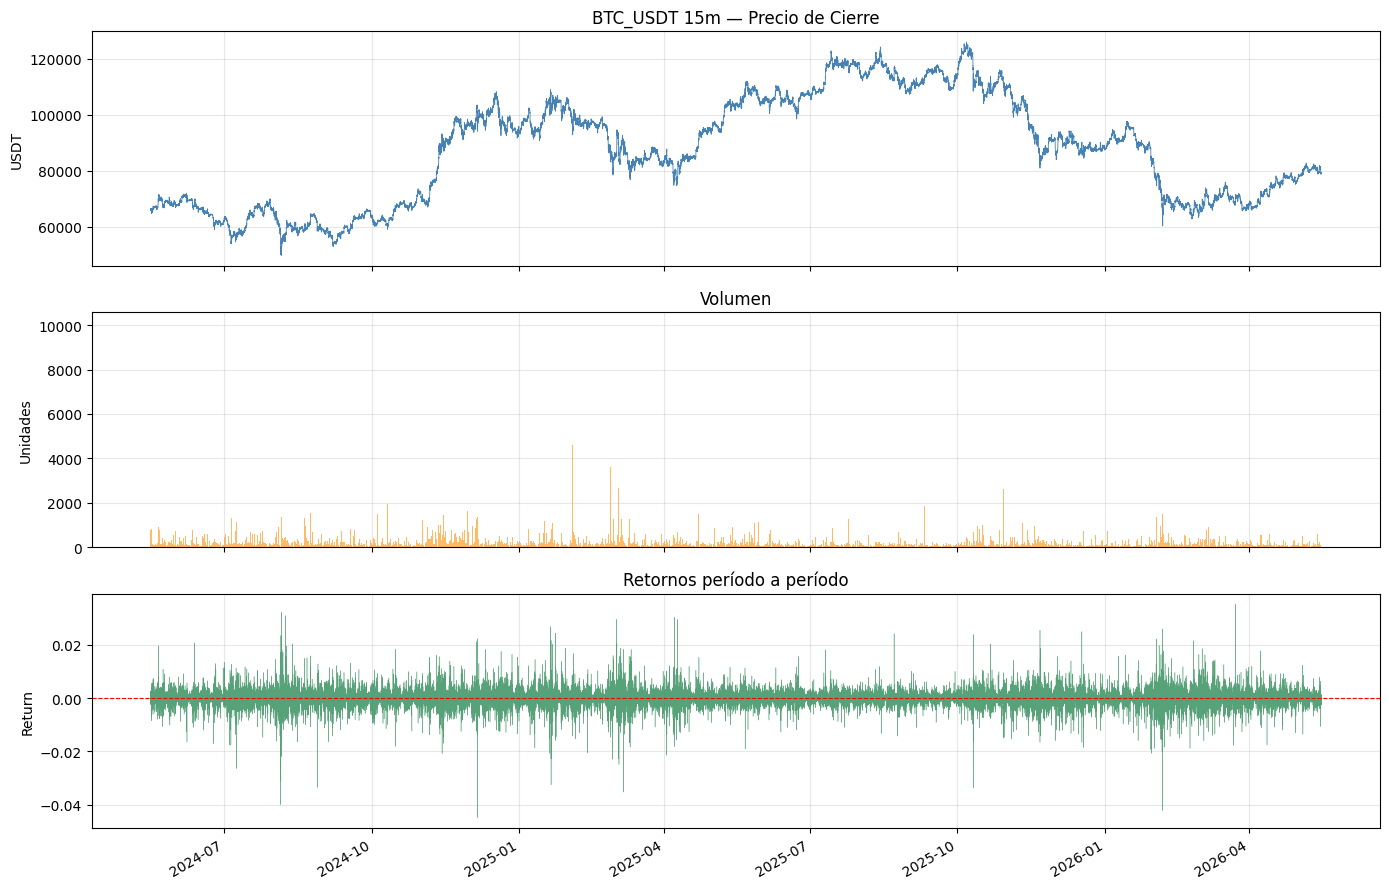

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(df.index, df['close'], linewidth=0.6, color='steelblue')
axes[0].set_title(f'{SYMBOL} {TIMEFRAME} — Precio de Cierre', fontsize=12)
axes[0].set_ylabel('USDT')
axes[0].grid(True, alpha=0.3)

axes[1].bar(df.index, df['volume'], width=0.01, color='darkorange', alpha=0.6)
axes[1].set_title('Volumen', fontsize=12)
axes[1].set_ylabel('Unidades')
axes[1].grid(True, alpha=0.3)

ret = df['close'].pct_change()
axes[2].plot(df.index, ret, linewidth=0.3, color='seagreen', alpha=0.8)
axes[2].axhline(0, color='red', linewidth=0.8, linestyle='--')
axes[2].set_title('Retornos período a período', fontsize=12)
axes[2].set_ylabel('Return')
axes[2].grid(True, alpha=0.3)

axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 3. TDA: Fundamento Teórico

### Embedding de Takens
$$\Phi_\tau^d(t) = (x_t,\; x_{t+\tau},\; x_{t+2\tau},\; \ldots,\; x_{t+(d-1)\tau})$$

### Homología Persistente
El complejo de Vietoris-Rips $\text{VR}(X,\epsilon)$ sobre la nube de puntos $X$ produce un **diagrama de persistencia** $\{(b_i, d_i)\}$ que registra el nacimiento y muerte de componentes conectadas ($H_0$) y bucles ($H_1$) conforme $\epsilon$ crece.

### Distancia de Wasserstein
$$W_p(D_1, D_2) = \left(\inf_{\eta} \sum_{x \in D_1} \|x - \eta(x)\|_\infty^p \right)^{1/p}$$

**Amplitud de Wasserstein** (distancia al diagrama vacío):
$$W_p(D, \emptyset) = \left(\sum_{(b,d) \in D} \left(\frac{d-b}{2}\right)^p\right)^{1/p}$$

## 4. Extracción de Features TDA

In [5]:
# ── Normalización min-max ─────────────────────────────────────────────────
close      = df['close'].values.astype(np.float64)
close_norm = (close - close.min()) / (close.max() - close.min())

# ── Ventanas deslizantes ──────────────────────────────────────────────────
def sliding_windows(series: np.ndarray, size: int, stride: int) -> np.ndarray:
    starts = np.arange(0, len(series) - size + 1, stride)
    return series[starts[:, None] + np.arange(size)[None, :]]


windows   = sliding_windows(close_norm, WINDOW_SIZE, STRIDE)
n_windows = len(windows)

end_pos           = np.arange(n_windows) * STRIDE + (WINDOW_SIZE - 1)
window_timestamps = df.index[end_pos]

print(f"Ventanas: {n_windows:,}  |  shape: {windows.shape}")
print(f"Rango   : {window_timestamps[0].date()} → {window_timestamps[-1].date()}")

Ventanas: 17,508  |  shape: (17508, 50)
Rango   : 2024-05-16 → 2026-05-15


1/4  Embedding de Takens...
     Shape: (17508, 46, 3)  (ventanas × puntos × dim)


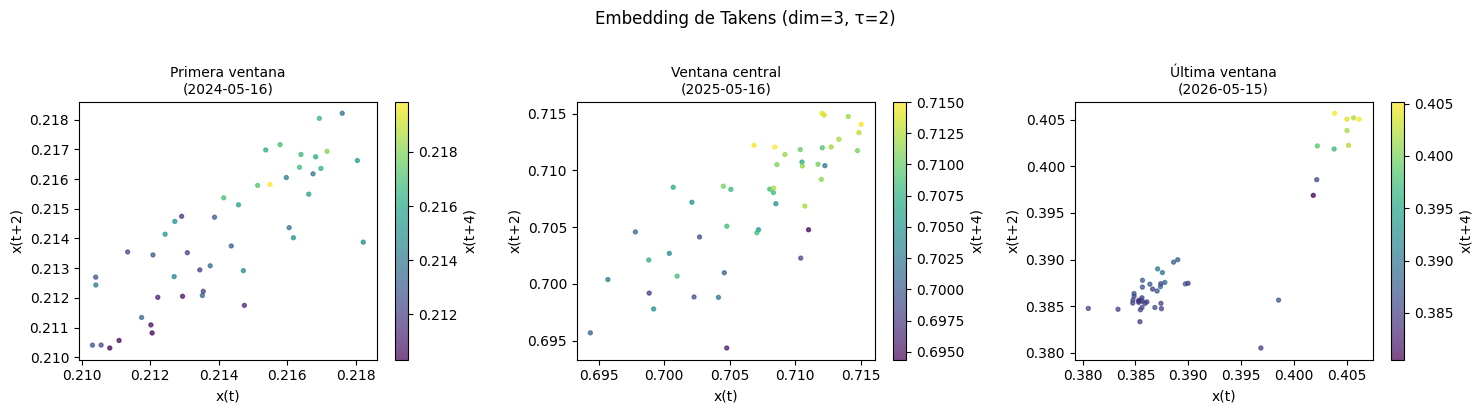

In [6]:
# ── Embedding de Takens (NumPy puro) ──────────────────────────────────────
def takens_embed(window: np.ndarray, dim: int, delay: int) -> np.ndarray:
    """Convierte una ventana 1-D en nube de puntos dim-D."""
    n_pts = len(window) - (dim - 1) * delay
    idx   = np.arange(dim)[None, :] * delay + np.arange(n_pts)[:, None]
    return window[idx]  # (n_pts, dim)


print("1/4  Embedding de Takens...")
point_clouds = np.array([
    takens_embed(w, TAKENS_DIM, TAKENS_DELAY) for w in windows
])
print(f"     Shape: {point_clouds.shape}  (ventanas × puntos × dim)")

# Visualización: nube de puntos de tres ventanas
sample_idx = [0, n_windows // 2, n_windows - 1]
labels_v   = ['Primera ventana', 'Ventana central', 'Última ventana']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, idx, lbl in zip(axes, sample_idx, labels_v):
    pc = point_clouds[idx]
    sc = ax.scatter(pc[:, 0], pc[:, 1], c=pc[:, 2], cmap='viridis', s=8, alpha=0.7)
    ax.set_title(f'{lbl}\n({window_timestamps[idx].date()})', fontsize=10)
    ax.set_xlabel('x(t)')
    ax.set_ylabel(f'x(t+{TAKENS_DELAY})')
    plt.colorbar(sc, ax=ax, label=f'x(t+{2*TAKENS_DELAY})')
plt.suptitle(f'Embedding de Takens (dim={TAKENS_DIM}, τ={TAKENS_DELAY})', y=1.02)
plt.tight_layout()
plt.show()

In [7]:
# ── Homología Persistente via ripser ──────────────────────────────────────
print("2/4  Computando homología persistente (ripser)...")
print(f"     {n_windows:,} ventanas — ~{n_windows//60:.0f} min estimado")

all_diagrams = []   # lista de listas: [dgms[0]=H0, dgms[1]=H1] por ventana
for pc in tqdm(point_clouds, desc='VR Persistencia'):
    result = ripser(pc, maxdim=1)
    all_diagrams.append(result['dgms'])  # dgms[0]: (n,2), dgms[1]: (m,2)

print(f"     {len(all_diagrams)} diagramas computados.")

2/4  Computando homología persistente (ripser)...
     17,508 ventanas — ~291 min estimado


VR Persistencia:   0%|          | 0/17508 [00:00<?, ?it/s]

     17508 diagramas computados.


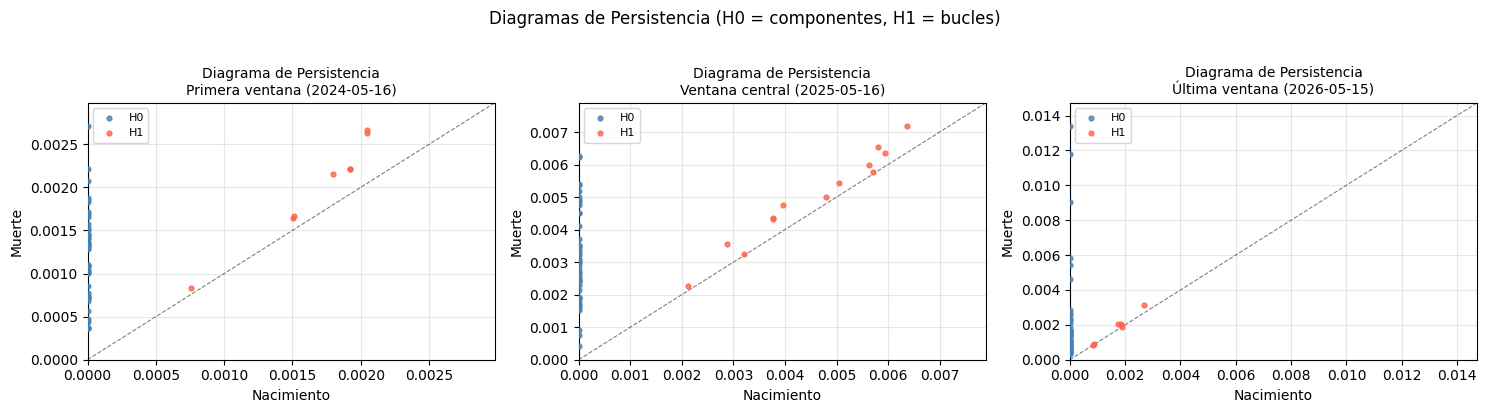

In [8]:
# ── Visualizar diagramas de persistencia ──────────────────────────────────
def finite_pts(dgm: np.ndarray) -> np.ndarray:
    """Filtra puntos con muerte infinita."""
    return dgm[np.isfinite(dgm[:, 1])]


fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, idx, lbl in zip(axes, sample_idx, labels_v):
    h0 = finite_pts(all_diagrams[idx][0])
    h1 = finite_pts(all_diagrams[idx][1])

    ax.scatter(h0[:, 0], h0[:, 1], c='steelblue', s=12, alpha=0.8, label='H0', zorder=3)
    ax.scatter(h1[:, 0], h1[:, 1], c='tomato',    s=12, alpha=0.8, label='H1', zorder=3)

    all_finite = np.concatenate([h0, h1]) if len(h1) else h0
    lim = float(np.max(all_finite[:, 1])) * 1.1 if len(all_finite) else 0.1
    ax.plot([0, lim], [0, lim], 'k--', linewidth=0.8, alpha=0.5)
    ax.set(xlim=(0, lim), ylim=(0, lim), xlabel='Nacimiento', ylabel='Muerte')
    ax.set_title(f'Diagrama de Persistencia\n{lbl} ({window_timestamps[idx].date()})', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Diagramas de Persistencia (H0 = componentes, H1 = bucles)', y=1.02)
plt.tight_layout()
plt.show()

In [9]:
# ── Amplitud de Wasserstein W_p(D, ∅) ─────────────────────────────────────
def wasserstein_amplitude(dgm: np.ndarray, p: float = 2.0) -> float:
    """Distancia de Wasserstein del diagrama al diagrama vacío.
    W_p(D, ∅) = (∑_i ((d_i - b_i)/2)^p)^(1/p)  sobre puntos finitos.
    """
    fin = finite_pts(dgm)
    if len(fin) == 0:
        return 0.0
    lifetimes = (fin[:, 1] - fin[:, 0]) / 2.0
    return float(np.sum(lifetimes ** p) ** (1.0 / p))


print("3/4  Amplitudes de Wasserstein...")
wass_amp_h0 = np.array([wasserstein_amplitude(d[0]) for d in all_diagrams])
wass_amp_h1 = np.array([wasserstein_amplitude(d[1]) for d in all_diagrams])
n_pts_h0    = np.array([len(finite_pts(d[0])) for d in all_diagrams], dtype=float)
n_pts_h1    = np.array([len(finite_pts(d[1])) for d in all_diagrams], dtype=float)

# ── Distancia de Wasserstein temporal (ventana i vs. i-1) ─────────────────
print("4/4  Distancias de Wasserstein temporales...")
wass_temp_h0 = np.zeros(n_windows)
wass_temp_h1 = np.zeros(n_windows)

for i in tqdm(range(1, n_windows), desc='Wasserstein temporal'):
    d0c, d0p = finite_pts(all_diagrams[i][0]),     finite_pts(all_diagrams[i-1][0])
    d1c, d1p = finite_pts(all_diagrams[i][1]),     finite_pts(all_diagrams[i-1][1])
    wass_temp_h0[i] = wasserstein_distance(d0c, d0p, order=2., internal_p=2.)
    wass_temp_h1[i] = wasserstein_distance(d1c, d1p, order=2., internal_p=2.)

print("Features TDA listos.")

3/4  Amplitudes de Wasserstein...
4/4  Distancias de Wasserstein temporales...


Wasserstein temporal:   0%|          | 0/17507 [00:00<?, ?it/s]

Features TDA listos.


In [10]:
tda_features = pd.DataFrame({
    'wass_amp_h0':  wass_amp_h0,
    'wass_amp_h1':  wass_amp_h1,
    'wass_temp_h0': wass_temp_h0,
    'wass_temp_h1': wass_temp_h1,
    'n_pts_h0':     n_pts_h0,
    'n_pts_h1':     n_pts_h1,
}, index=window_timestamps)

print("Estadísticas features TDA:")
print(tda_features.describe().round(4).to_string())

Estadísticas features TDA:
       wass_amp_h0  wass_amp_h1  wass_temp_h0  wass_temp_h1  n_pts_h0    n_pts_h1
count   17508.0000   17508.0000    17508.0000    17508.0000   17508.0  17508.0000
mean        0.0104       0.0010        0.0025        0.0008      45.0      8.6462
std         0.0062       0.0008        0.0029        0.0008       0.0      2.9979
min         0.0008       0.0000        0.0000        0.0000      45.0      0.0000
25%         0.0063       0.0005        0.0009        0.0003      45.0      7.0000
50%         0.0090       0.0008        0.0016        0.0006      45.0      9.0000
75%         0.0130       0.0012        0.0028        0.0010      45.0     11.0000
max         0.0665       0.0129        0.0687        0.0194      45.0     23.0000


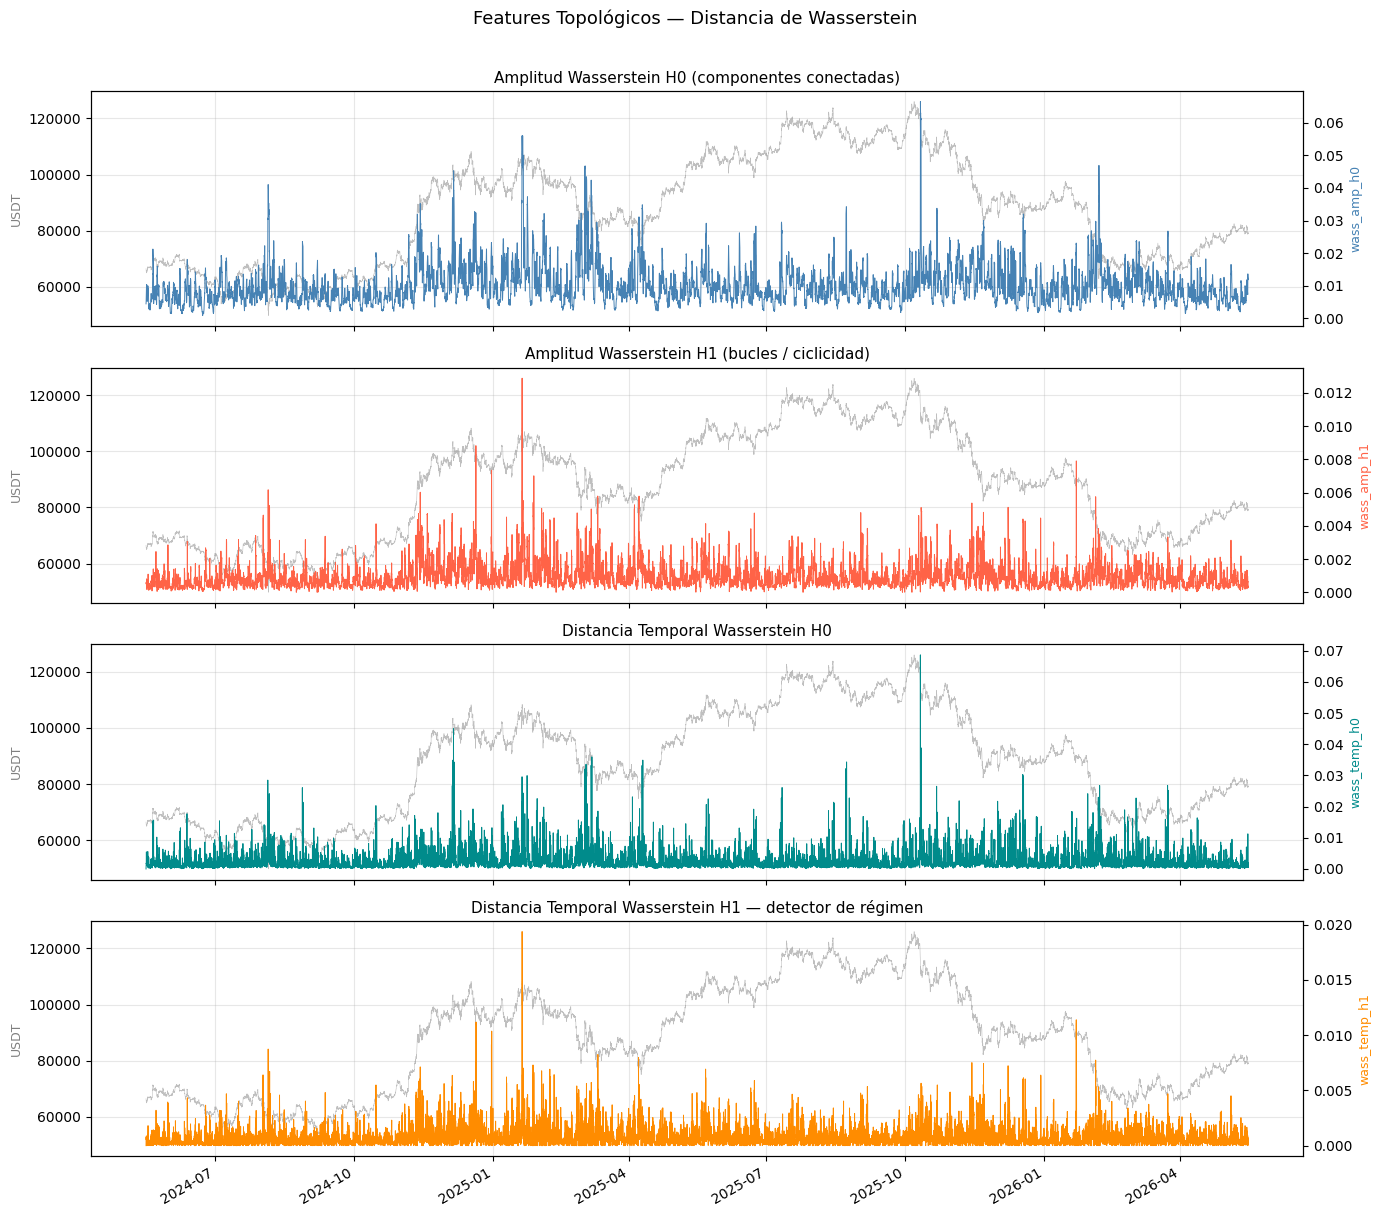

In [11]:
price_at_windows = df.loc[window_timestamps, 'close']

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
cfg = [
    ('wass_amp_h0',  'steelblue', 'Amplitud Wasserstein H0 (componentes conectadas)'),
    ('wass_amp_h1',  'tomato',    'Amplitud Wasserstein H1 (bucles / ciclicidad)'),
    ('wass_temp_h0', 'darkcyan',  'Distancia Temporal Wasserstein H0'),
    ('wass_temp_h1', 'darkorange','Distancia Temporal Wasserstein H1 — detector de régimen'),
]
for ax, (feat, color, title) in zip(axes, cfg):
    ax2 = ax.twinx()
    ax.plot(window_timestamps, price_at_windows, color='gray', linewidth=0.4, alpha=0.5)
    ax2.plot(window_timestamps, tda_features[feat], color=color, linewidth=0.7)
    ax.set_ylabel('USDT', color='gray', fontsize=9)
    ax2.set_ylabel(feat, color=color, fontsize=9)
    ax.set_title(title, fontsize=11)
    ax.grid(True, alpha=0.3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30, ha='right')
plt.suptitle('Features Topológicos — Distancia de Wasserstein', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 5. Features Técnicos Clásicos (TA)

In [12]:
def compute_ta_features(df: pd.DataFrame) -> pd.DataFrame:
    feat  = pd.DataFrame(index=df.index)
    close = df['close']
    high, low, vol = df['high'], df['low'], df['volume']

    for p in [1, 4, 8, 16, 32]:
        feat[f'ret_{p}'] = close.pct_change(p)

    log_ret = np.log(close / close.shift(1))
    for w in [8, 16, 32, 64]:
        feat[f'vol_{w}'] = log_ret.rolling(w).std()

    delta = close.diff()
    gain  = delta.clip(lower=0).ewm(span=14, adjust=False).mean()
    loss  = (-delta.clip(upper=0)).ewm(span=14, adjust=False).mean()
    feat['rsi_14'] = 100 - 100 / (1 + gain / (loss + 1e-10))

    ema12  = close.ewm(span=12, adjust=False).mean()
    ema26  = close.ewm(span=26, adjust=False).mean()
    macd   = ema12 - ema26
    feat['macd']      = macd / close
    feat['macd_hist'] = (macd - macd.ewm(span=9, adjust=False).mean()) / close

    bb_mid = close.rolling(20).mean()
    bb_std = close.rolling(20).std()
    feat['bb_pos']   = (close - bb_mid) / (2 * bb_std + 1e-10)
    feat['bb_width'] = (4 * bb_std) / (bb_mid + 1e-10)

    tr = np.maximum(high - low, np.maximum(
        abs(high - close.shift(1)), abs(low - close.shift(1))))
    feat['atr_14']   = tr.rolling(14).mean() / close
    feat['hl_range'] = (high - low) / close
    feat['vol_ratio'] = vol / (vol.rolling(20).mean() + 1e-10)
    feat['vol_pct']   = vol.pct_change()

    for span in [8, 21, 50, 100]:
        ema = close.ewm(span=span, adjust=False).mean()
        feat[f'ema{span}_rel'] = (close - ema) / ema

    return feat


ta_features = compute_ta_features(df)
print(f"Features TA: {ta_features.shape[1]} columnas")

Features TA: 22 columnas


## 6. Variable Objetivo: Señal de Trading

  Hold  : 62,889  (89.7%)
  Sell  : 3,749  (5.3%)
  Buy   : 3,443  (4.9%)


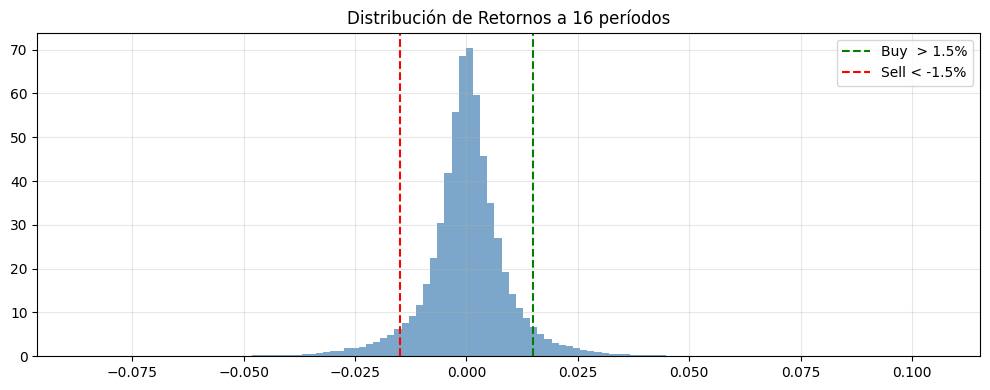

In [13]:
def make_target(df, future, buy_thresh, sell_thresh):
    fut_ret = df['close'].pct_change(future).shift(-future)
    signal  = pd.Series('Hold', index=df.index, dtype=str)
    signal[fut_ret >= buy_thresh]  = 'Buy'
    signal[fut_ret <= sell_thresh] = 'Sell'
    return signal, fut_ret


signal, future_return = make_target(
    df, FUTURE_PERIODS, BUY_THRESHOLD, SELL_THRESHOLD)

counts = signal.value_counts()
for lbl, cnt in counts.items():
    print(f"  {lbl:5s} : {cnt:,}  ({cnt/len(signal)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 4))
future_return.dropna().hist(bins=120, ax=ax, color='steelblue', alpha=0.7, density=True)
ax.axvline(BUY_THRESHOLD,  color='green', linestyle='--', linewidth=1.5,
           label=f'Buy  > {BUY_THRESHOLD:.1%}')
ax.axvline(SELL_THRESHOLD, color='red',   linestyle='--', linewidth=1.5,
           label=f'Sell < {SELL_THRESHOLD:.1%}')
ax.set_title(f'Distribución de Retornos a {FUTURE_PERIODS} períodos')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Ensamble de la Matriz de Features

In [14]:
combined = ta_features.join(tda_features, how='inner')
combined['target']        = signal
combined['future_return'] = future_return
combined = combined.iloc[:-FUTURE_PERIODS].dropna()

FEATURE_COLS = [c for c in combined.columns if c not in ['target', 'future_return']]
TDA_COLS     = list(tda_features.columns)
TA_COLS      = [c for c in FEATURE_COLS if c not in TDA_COLS]

print(f"Matriz  : {combined.shape}")
print(f"  TA    : {len(TA_COLS)} features")
print(f"  TDA   : {len(TDA_COLS)} features")
print(f"\nClases  : {dict(combined['target'].value_counts())}")

Matriz  : (17488, 30)
  TA    : 22 features
  TDA   : 6 features

Clases  : {'Hold': 15683, 'Sell': 931, 'Buy': 874}


## 8. Split Temporal Train / Test

In [15]:
n_train = int(len(combined) * TRAIN_FRAC)
train, test = combined.iloc[:n_train], combined.iloc[n_train:]

X_train, X_test = train[FEATURE_COLS], test[FEATURE_COLS]

LABEL_MAP     = {'Buy': 0, 'Hold': 1, 'Sell': 2}
INV_LABEL_MAP = {v: k for k, v in LABEL_MAP.items()}

y_train = train['target'].map(LABEL_MAP)
y_test  = test['target'].map(LABEL_MAP)

print(f"Train : {len(X_train):,}  ({train.index.min().date()} → {train.index.max().date()})")
print(f"Test  : {len(X_test):,}  ({test.index.min().date()} → {test.index.max().date()})")

Train : 13,990  (2024-05-16 → 2025-12-20)
Test  : 3,498  (2025-12-20 → 2026-05-15)


## 9. Modelo XGBoost

In [16]:
class_counts  = y_train.value_counts().sort_index()
sample_weight = y_train.map(
    {cls: len(y_train) / (len(LABEL_MAP) * cnt)
     for cls, cnt in class_counts.items()}
)

model = xgb.XGBClassifier(
    n_estimators          = 600,
    max_depth             = 5,
    learning_rate         = 0.05,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    min_child_weight      = 5,
    gamma                 = 0.1,
    reg_alpha             = 0.1,
    reg_lambda            = 1.0,
    objective             = 'multi:softprob',
    num_class             = 3,
    eval_metric           = 'mlogloss',
    early_stopping_rounds = 30,
    n_jobs                = -1,
    random_state          = 42,
)

model.fit(
    X_train, y_train,
    sample_weight = sample_weight,
    eval_set      = [(X_test, y_test)],
    verbose       = 100,
)

print(f"\nMejor iteración : {model.best_iteration}")
print(f"Mejor mlogloss  : {model.best_score:.4f}")

[0]	validation_0-mlogloss:1.08647
[100]	validation_0-mlogloss:0.85417
[200]	validation_0-mlogloss:0.77195
[300]	validation_0-mlogloss:0.70269
[400]	validation_0-mlogloss:0.64572
[500]	validation_0-mlogloss:0.59925
[599]	validation_0-mlogloss:0.56204

Mejor iteración : 599
Mejor mlogloss  : 0.5620


## 10. Evaluación del Modelo

              precision    recall  f1-score   support

         Buy       0.12      0.20      0.15       174
        Hold       0.91      0.88      0.90      3140
        Sell       0.05      0.05      0.05       184

    accuracy                           0.81      3498
   macro avg       0.36      0.38      0.37      3498
weighted avg       0.83      0.81      0.82      3498



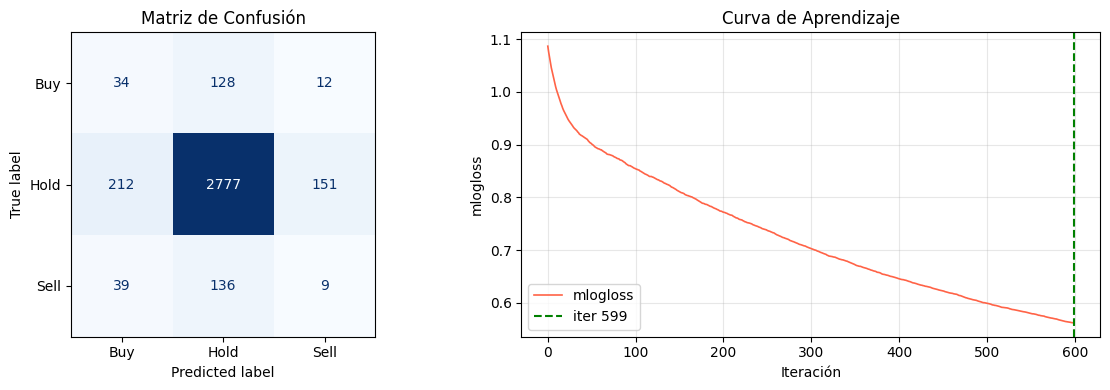

In [17]:
y_pred      = model.predict(X_test)
y_pred_lbls = pd.Series(y_pred, index=test.index).map(INV_LABEL_MAP)
y_test_lbls = y_test.map(INV_LABEL_MAP)

print(classification_report(y_test_lbls, y_pred_lbls))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm = confusion_matrix(y_test_lbls, y_pred_lbls, labels=['Buy', 'Hold', 'Sell'])
ConfusionMatrixDisplay(cm, display_labels=['Buy', 'Hold', 'Sell']).plot(
    cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title('Matriz de Confusión')

log = model.evals_result()['validation_0']['mlogloss']
axes[1].plot(log, color='tomato', linewidth=1.2, label='mlogloss')
axes[1].axvline(model.best_iteration, color='green', linestyle='--',
                label=f'iter {model.best_iteration}')
axes[1].set(xlabel='Iteración', ylabel='mlogloss', title='Curva de Aprendizaje')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Importancia de Features

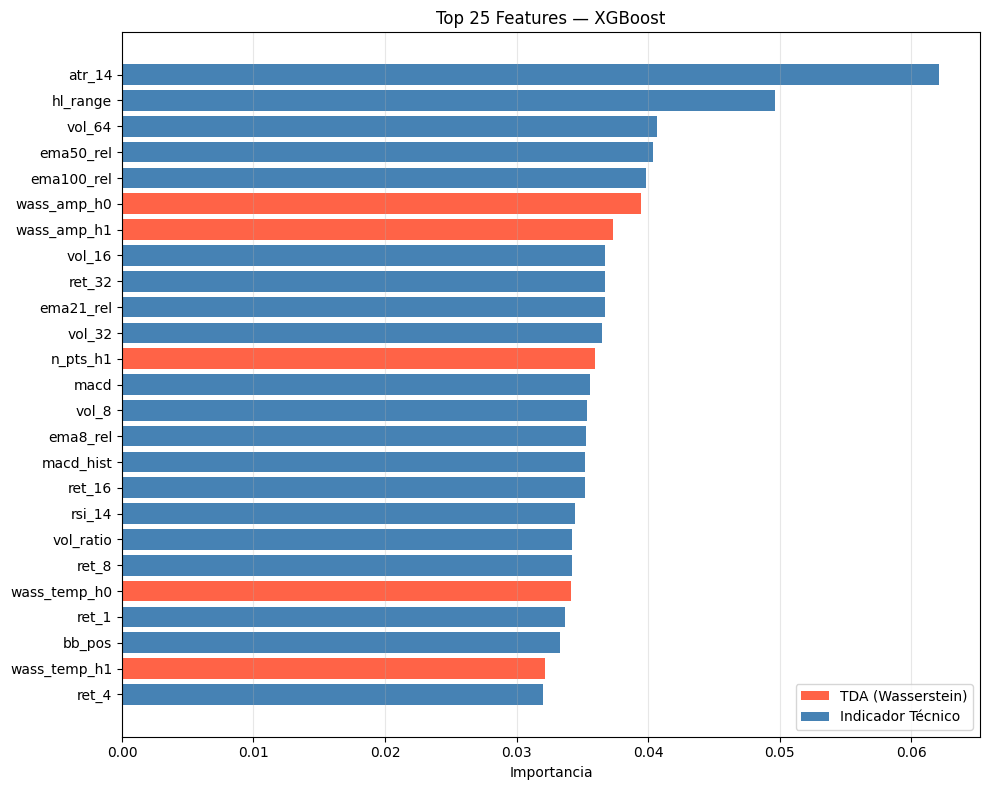

Importancia TDA : 17.9%
Importancia TA  : 82.1%

Detalle TDA:
     feature  importance              tipo
 wass_amp_h0    0.039479 TDA (Wasserstein)
 wass_amp_h1    0.037333 TDA (Wasserstein)
    n_pts_h1    0.035985 TDA (Wasserstein)
wass_temp_h0    0.034129 TDA (Wasserstein)
wass_temp_h1    0.032125 TDA (Wasserstein)
    n_pts_h0    0.000000 TDA (Wasserstein)


In [18]:
importance_df = pd.DataFrame({
    'feature':    FEATURE_COLS,
    'importance': model.feature_importances_,
}).sort_values('importance', ascending=False).reset_index(drop=True)

importance_df['tipo'] = importance_df['feature'].apply(
    lambda x: 'TDA (Wasserstein)' if x in TDA_COLS else 'Indicador Técnico'
)

top    = importance_df.head(25)
colors = top['tipo'].map({'TDA (Wasserstein)': 'tomato', 'Indicador Técnico': 'steelblue'}).values

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top['feature'], top['importance'], color=colors)
ax.invert_yaxis()
ax.set_xlabel('Importancia')
ax.set_title('Top 25 Features — XGBoost', fontsize=12)
ax.legend(handles=[
    Patch(facecolor='tomato',    label='TDA (Wasserstein)'),
    Patch(facecolor='steelblue', label='Indicador Técnico'),
], loc='lower right')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

tda_imp = importance_df[importance_df['tipo'] == 'TDA (Wasserstein)']['importance'].sum()
ta_imp  = importance_df[importance_df['tipo'] == 'Indicador Técnico']['importance'].sum()
total   = tda_imp + ta_imp
print(f"Importancia TDA : {tda_imp/total*100:.1f}%")
print(f"Importancia TA  : {ta_imp/total*100:.1f}%")
print("\nDetalle TDA:")
print(importance_df[importance_df['tipo'] == 'TDA (Wasserstein)'].to_string(index=False))

## 12. Backtesting

In [20]:
def run_backtest(test_df, signals, initial_capital=INITIAL_CAPITAL, fee=FEE):
    closes    = test_df['close'].values
    sigs      = signals.values
    capital   = initial_capital
    position  = 0.0
    buy_price = 0.0
    portfolio = np.zeros(len(closes))
    trades    = []

    for i, (price, action) in enumerate(zip(closes, sigs)):
        if action == 'Buy' and position == 0.0 and capital > 0:
            position  = capital * (1 - fee) / price
            buy_price = price
            capital   = 0.0
            trades.append({'type': 'buy', 'price': price})
        elif action == 'Sell' and position > 0.0:
            capital  = position * price * (1 - fee)
            trades.append({'type': 'sell', 'price': price,
                           'return': (price - buy_price) / buy_price})
            position = 0.0
        portfolio[i] = capital + position * price

    return pd.DataFrame({
        'close': closes, 'portfolio': portfolio,
        'bh': initial_capital * closes / closes[0],
        'signal': sigs,
    }, index=test_df.index), trades


bt, trades = run_backtest(df.loc[test.index], y_pred_lbls)

strat_r = (bt['portfolio'].iloc[-1] - INITIAL_CAPITAL) / INITIAL_CAPITAL
bh_r    = (bt['bh'].iloc[-1]        - INITIAL_CAPITAL) / INITIAL_CAPITAL
sells   = [t for t in trades if t['type'] == 'sell']
rets    = [t['return'] for t in sells]

print(f"Retorno estrategia  : {strat_r:+.2%}")
print(f"Retorno Buy & Hold  : {bh_r:+.2%}")
print(f"Trades cerrados     : {len(sells)}")
if rets:
    print(f"Win rate            : {sum(1 for r in rets if r > 0)/len(rets):.1%}")
    print(f"Retorno medio/trade : {np.mean(rets):+.2%}")

Retorno estrategia  : -23.76%
Retorno Buy & Hold  : -8.71%
Trades cerrados     : 92
Win rate            : 58.7%
Retorno medio/trade : -0.07%


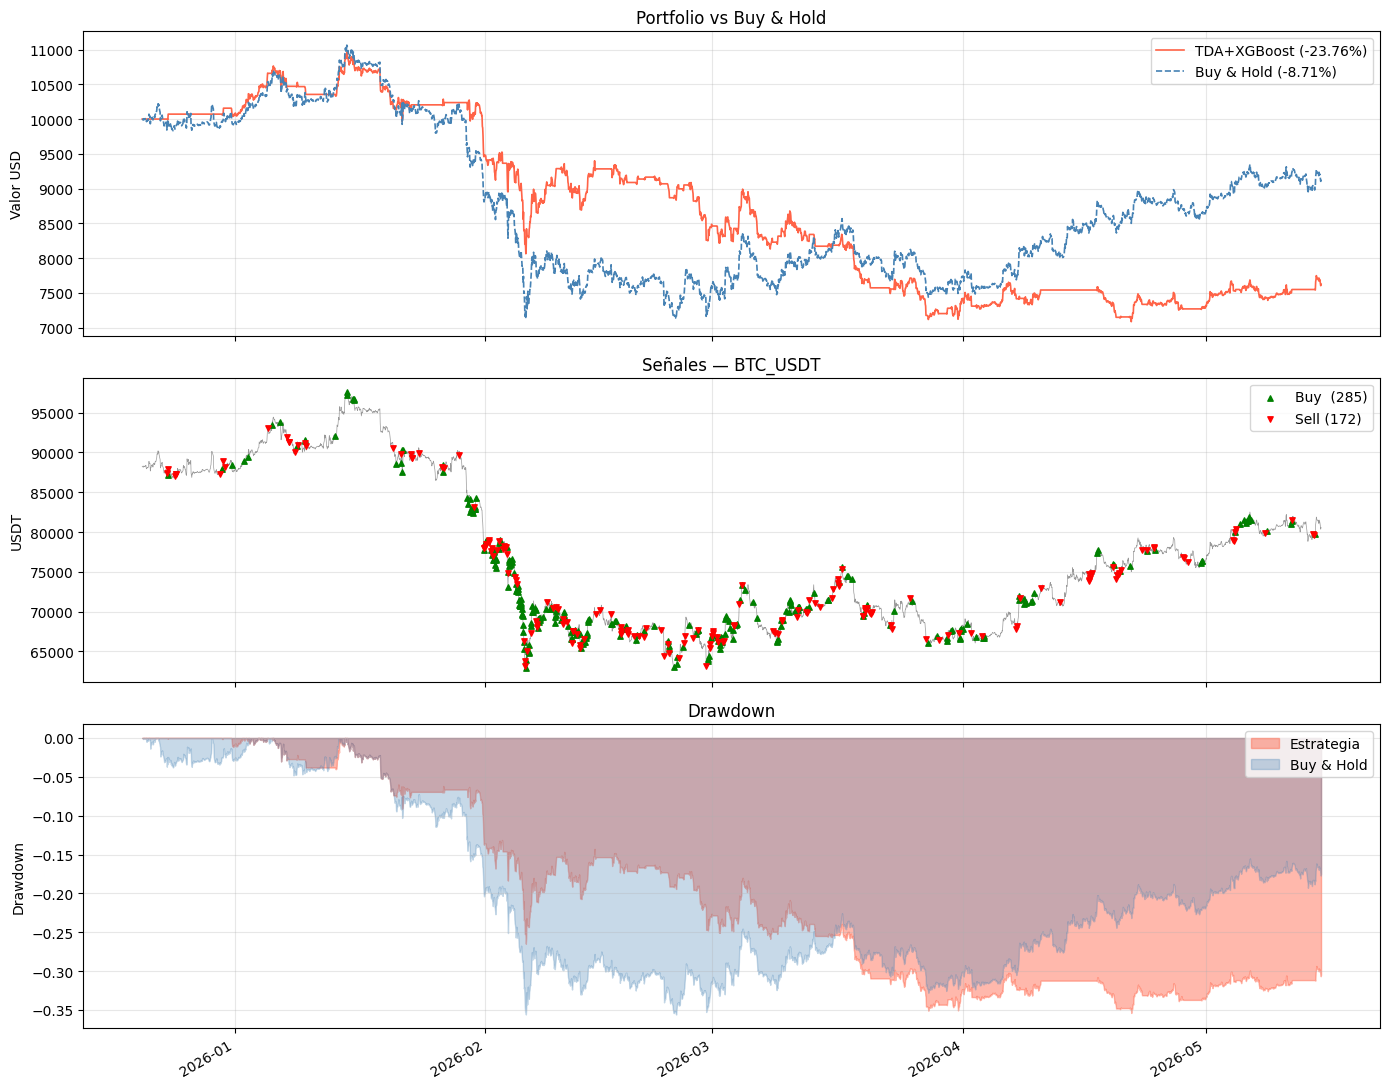

Max DD Estrategia : -35.39%
Max DD Buy & Hold : -35.59%


In [21]:
def drawdown(s): return (s - s.cummax()) / s.cummax()

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

axes[0].plot(bt.index, bt['portfolio'], color='tomato',
             linewidth=1.2, label=f'TDA+XGBoost ({strat_r:+.2%})')
axes[0].plot(bt.index, bt['bh'], color='steelblue', linestyle='--',
             linewidth=1.2, label=f'Buy & Hold ({bh_r:+.2%})')
axes[0].set(title='Portfolio vs Buy & Hold', ylabel='Valor USD')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

buy_m  = bt['signal'] == 'Buy'
sell_m = bt['signal'] == 'Sell'
axes[1].plot(bt.index, bt['close'], color='gray', linewidth=0.5, alpha=0.8)
axes[1].scatter(bt.index[buy_m],  bt['close'][buy_m],  marker='^', color='green',
                s=15, zorder=5, label=f'Buy  ({buy_m.sum()})')
axes[1].scatter(bt.index[sell_m], bt['close'][sell_m], marker='v', color='red',
                s=15, zorder=5, label=f'Sell ({sell_m.sum()})')
axes[1].set(title=f'Señales — {SYMBOL}', ylabel='USDT')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

dd_s  = drawdown(bt['portfolio'])
dd_bh = drawdown(bt['bh'])
axes[2].fill_between(bt.index, dd_s,  0, alpha=0.45, color='tomato',    label='Estrategia')
axes[2].fill_between(bt.index, dd_bh, 0, alpha=0.30, color='steelblue', label='Buy & Hold')
axes[2].set(title='Drawdown', ylabel='Drawdown')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.show()

print(f"Max DD Estrategia : {dd_s.min():.2%}")
print(f"Max DD Buy & Hold : {dd_bh.min():.2%}")

## 13. Conclusiones

### Features TDA extraídos

| Feature | Interpretación financiera |
|---|---|
| `wass_amp_h0` | Dispersión de la nube de precio — energía topológica de los componentes |
| `wass_amp_h1` | Ciclicidad de la trayectoria del precio en el espacio de fase |
| `wass_temp_h0` | Cambio de momentum topológico en componentes consecutivos |
| `wass_temp_h1` | **Detector de cambio de régimen** — ruptura de estructura cíclica |
| `n_pts_h0 / h1` | Complejidad topológica multiescala |

### Pipeline sin giotto-tda
- **Embedding de Takens**: NumPy puro — sin dependencias externas.
- **Homología persistente**: `ripser` (C++ bindings, rápido y estable).
- **Distancia de Wasserstein**: `gudhi` + `POT` — implementación de referencia.

### Posibles mejoras
1. **Hiperparámetros TDA**: búsqueda bayesiana sobre dim, τ, window_size.
2. **Features adicionales**: Landscape persistente, entropía de persistencia.
3. **Modelo temporal**: LSTM sobre la secuencia de features TDA.
4. **Multi-par**: cambiar `SYMBOL` y re-ejecutar; comparar importancias por par.